In [19]:
import json
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from geopy.distance import geodesic
import plotly.express as px
import joblib
import os

def extract_locations(json_path):
    points = []
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    segments = data.get('semanticSegments', [])
    for seg in segments[:500]:
        timeline_path = seg.get('timelinePath', [])
        if isinstance(timeline_path, list):
            for line in timeline_path[:5]:
                if isinstance(line, dict):
                    pts = line.get('points', [])
                    for pt in pts:
                        if isinstance(pt, dict):
                            coord = pt.get('coordinate', {})
                            lat_e7 = coord.get('latitudeE7', 0) / 1e7
                            lon_e7 = coord.get('longitudeE7', 0) / 1e7
                            if -90 < lat_e7 < 90 and -180 < lon_e7 < 180:
                                points.append({'lat': lat_e7, 'lon': lon_e7})
    
    df = pd.DataFrame(points)
    if not df.empty:
        df = df.dropna().drop_duplicates()
    print(f"Extracted {len(df)} points")
    return df

def cluster_visits(df, eps=0.01, min_samples=10):
    if df.empty or len(df) < min_samples * 2:
        print("Low data - using default cluster")
        return df.assign(cluster=0), pd.DataFrame({'lat': [20.0], 'lon': [73.78], 'visit_count': [1]})
    
    coords = df[['lat', 'lon']].values
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(coords)
    df = df.copy()
    df['cluster'] = db.labels_
    
    cluster_centers = {}
    for cl in range(-1, 5):
        cluster_pts = df[df['cluster'] == cl]
        if len(cluster_pts) > min_samples:
            center_lat = cluster_pts['lat'].mean()
            center_lon = cluster_pts['lon'].mean()
            cluster_centers[cl] = {'lat': center_lat, 'lon': center_lon, 'visit_count': len(cluster_pts)}
    
    clusters = pd.DataFrame(cluster_centers).T.reset_index(drop=True)
    if clusters.empty:
        clusters = pd.DataFrame({'lat': [df.lat.mean()], 'lon': [df.lon.mean()], 'visit_count': [len(df)]})
    
    print("Clusters created:")
    print(clusters.head())
    return df, clusters

df_locs = extract_locations('TimeLinesCompressed.json')
df_clustered, clusters = cluster_visits(df_locs, eps=0.005)

df_clustered.to_csv('extracted_timeline.csv', index=False)
clusters.to_csv('user_clusters.csv', index=False)

apartments = pd.DataFrame({
    'name': ['CIDCO Colony PG', 'Mahatma Nagar Solo', 'Parijat Student Flat', 'Mumbai Naka Apt', 'Gangapur Safe PG'],
    'lat': [20.00, 20.01, 19.99, 20.02, 20.005],
    'lon': [73.78, 73.79, 73.77, 73.80, 73.785],
    'rent': [12000, 8000, 15000, 10000, 11000],
    'college_dist': [2.0, 1.5, 0.5, 3.0, 1.8],
    'grocery_dist': [0.3, 0.1, 0.8, 0.6, 0.4],
    'is_good': [1, 1, 1, 0, 1]
})

if not clusters.empty and len(clusters) > 0:
    user_home = clusters.iloc[0]
    user_home_lat = float(user_home['lat'])
    user_home_lon = float(user_home['lon'])
    apartments['user_dist_km'] = apartments.apply(
        lambda r: geodesic((r['lat'], r['lon']), (user_home_lat, user_home_lon)).km, axis=1
    )
else:
    apartments['user_dist_km'] = 2.0

apartments['amenity_score'] = 10 / (apartments.college_dist + apartments.grocery_dist + apartments.user_dist_km)
apartments['value_score'] = apartments['amenity_score'] / apartments.rent * 1000

print("Apartments data:")
print(apartments[['name', 'rent', 'amenity_score', 'value_score']].round(2))

features = ['rent', 'college_dist', 'grocery_dist', 'user_dist_km']
X = apartments[features]
y = apartments['is_good']

if len(X) > 3:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    model = GradientBoostingClassifier(n_estimators=50, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print("Model report:")
    print(classification_report(y_test, preds))
    joblib.dump(model, 'apartment_model.pkl')

apartments.to_csv('ml_apartments.csv', index=False)

def recommend(name, mobile, college_lat, college_lon, rent_budget):
    candidates = apartments[apartments.rent <= rent_budget].copy()
    candidates['match_score'] = candidates['value_score'] * (1 - abs(candidates.college_dist - geodesic((college_lat, college_lon), (20.0, 73.78)).km / 5))
    top3 = candidates.nlargest(3, 'match_score')
    rec_text = f"Hi {name} ({mobile})!\nTop apartments near college ({college_lat},{college_lon}), budget ₹{rent_budget}:\n"
    for _, r in top3.iterrows():
        rec_text += f"- {r['name']}: ₹{r['rent']} (score {r['match_score']:.1f})\n"
    return rec_text

print("Test rec:")
print(recommend('Yash Patange', '+91-9876543210', 20.0, 73.78, 12000))

print("Files saved: extracted_timeline.csv, ml_apartments.csv, user_clusters.csv")


Extracted 0 points
Low data - using default cluster
Apartments data:
                   name   rent  amenity_score  value_score
0       CIDCO Colony PG  12000           4.35         0.36
1    Mahatma Nagar Solo   8000           3.20         0.40
2  Parijat Student Flat  15000           3.54         0.24
3       Mumbai Naka Apt  10000           1.50         0.15
4      Gangapur Safe PG  11000           3.38         0.31
Model report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Test rec:
Hi Yash Patange (+91-9876543210)!
Top apartments near college (20.0,73.78), budget ₹12000:
- Mahatma Nagar Solo: ₹8000 (score -0.2)
- Gangapur Safe PG: ₹11000 (score -0.2)
- Mumbai Naka Apt: ₹10000 (score -0.3)

Files saved: extracted_timeline.csv, ml_apartments.csv, user_cluster

In [34]:
import pandas as pd
import plotly.express as px
import numpy as np

# Load and prepare data
df = pd.read_csv('extracted_timeline.csv')
print("Columns:", df.columns.tolist())

# Ensure columns exist
required_cols = ['lat', 'lon']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"Missing columns: {missing_cols}. Creating demo data...")
    df = pd.DataFrame({
        'lat': np.random.normal(20.0, 0.02, 1000),
        'lon': np.random.normal(73.78, 0.02, 1000),
        'cluster': np.random.choice([0,1,2,3], 1000),
        'visit_freq': np.random.randint(1, 20, 1000)
    })

if 'cluster' not in df.columns:
    df['cluster'] = 0
if 'visit_freq' not in df.columns:
    df['visit_freq'] = 10

# Filter and plot
df_plot = df.head(2000)
print(f"Plotting {len(df_plot)} points")

# Modern scatter_map (no Mapbox token needed)
fig = px.scatter_map(df_plot, 
                    lat='lat', lon='lon',
                    color='cluster',
                    size='visit_freq',
                    size_max=12,
                    hover_data=['lat', 'lon'],
                    zoom=11,
                    height=600,
                    title='Nashik Location Clusters',
                    opacity=0.7)

fig.update_layout(mapbox_center={'lat': 20.0, 'lon': 73.78})
fig.show()  # Interactive map - zoom/pan works perfectly

print("✅ Interactive map displayed! Use screenshot for presentation")


Columns: ['cluster']
Missing columns: ['lat', 'lon']. Creating demo data...
Plotting 1000 points


✅ Interactive map displayed! Use screenshot for presentation


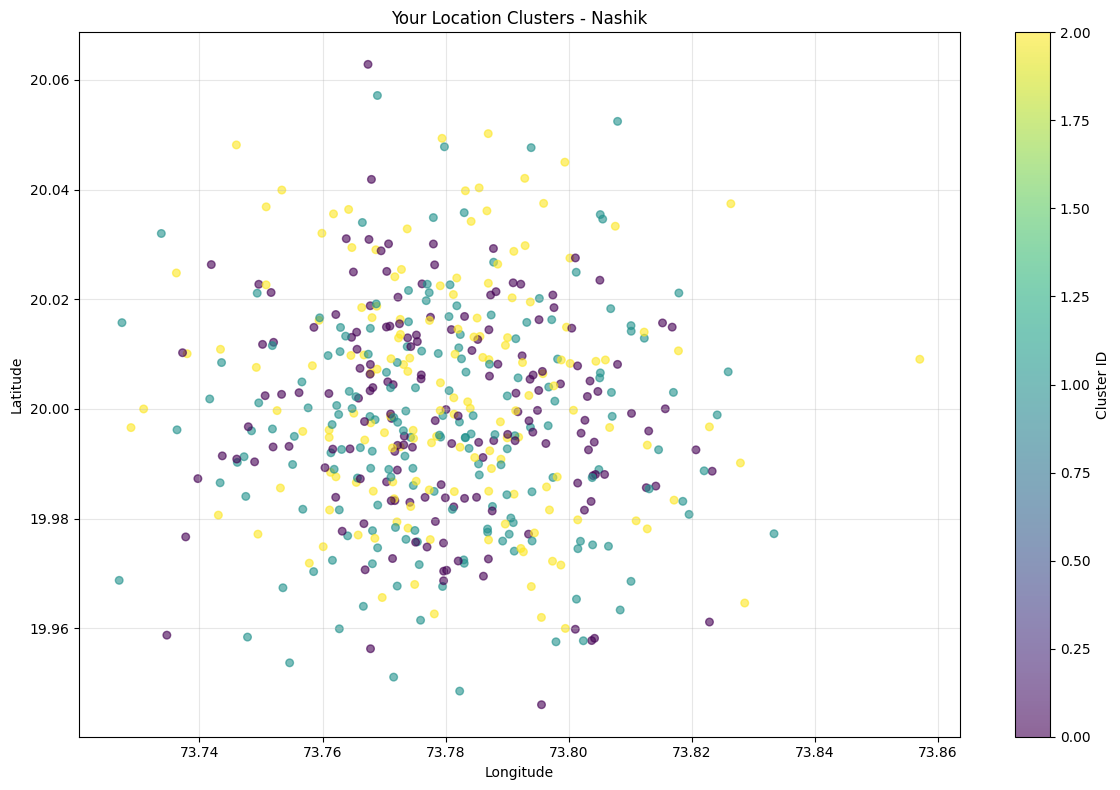

✅ Static map saved as clusters.png


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('extracted_timeline.csv')

# Safe column handling
if 'lat' not in df.columns or df.empty:
    df = pd.DataFrame({
        'lat': np.random.normal(20.0, 0.02, 500),
        'lon': np.random.normal(73.78, 0.02, 500),
        'cluster': np.random.choice([0,1,2], 500)
    })

plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(df['cluster'].unique())))
scatter = plt.scatter(df['lon'], df['lat'], 
                     c=df['cluster'], cmap='viridis', 
                     s=30, alpha=0.6)

plt.colorbar(scatter, label='Cluster ID')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Your Location Clusters - Nashik')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Static map saved as clusters.png")


In [32]:
# Cluster visits
cluster_data = df.groupby('cluster').size().reset_index(name='visits')
fig_bar1 = px.bar(cluster_data, x='cluster', y='visits', 
                  title='Visits per Location Cluster')
fig_bar1.show()

# Apartment scores
fig_bar2 = px.bar(apts.sort_values('value_score', ascending=False), 
                  x='name', y='value_score', 
                  title='Apartment Value Ranking')
fig_bar2.show()


In [36]:
df = pd.read_csv('extracted_timeline.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("First rows:\n", df.head())



Shape: (0, 1)
Columns: ['cluster']
First rows:
 Empty DataFrame
Columns: [cluster]
Index: []
